In [1]:
# Step 1: Load the datasets and check basic info
# !pip install pandas
import pandas as pd

# --------- 1. Kidney Disease Dataset ---------
kidney_df = pd.read_csv(r"C:/Users/KKARUNA/Downloads/kidney_disease - kidney_disease.csv")  # replace with your file path
print("=== Kidney Disease Dataset ===")
print("Head:\n", kidney_df.head())
print("\nColumns:", kidney_df.columns.tolist())
print("\nInfo:")
print(kidney_df.info())
print("\nUnique values per column:")
for col in kidney_df.columns:
    print(f"{col} --> {kidney_df[col].unique()[:10]}")  # first 10 unique values

# --------- 2. Parkinson's Disease Dataset ---------
parkinson_df = pd.read_csv(r"C:/Users/KKARUNA/Downloads/parkinsons - parkinsons.csv")  # replace with your file path
print("\n=== Parkinson's Disease Dataset ===")
print("Head:\n", parkinson_df.head())
print("\nColumns:", parkinson_df.columns.tolist())
print("\nInfo:")
print(parkinson_df.info())
print("\nUnique values per column:")
for col in parkinson_df.columns:
    print(f"{col} --> {parkinson_df[col].unique()[:10]}")

# --------- 3. Indian Liver Patient Dataset ---------
liver_df = pd.read_csv(r"C:/Users/KKARUNA/Downloads/indian_liver_patient - indian_liver_patient.csv")  # replace with your file path
print("\n=== Indian Liver Patient Dataset ===")
print("Head:\n", liver_df.head())
print("\nColumns:", liver_df.columns.tolist())
print("\nInfo:")
print(liver_df.info())
print("\nUnique values per column:")
for col in liver_df.columns:
    print(f"{col} --> {liver_df[col].unique()[:10]}")


=== Kidney Disease Dataset ===
Head:
    id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]

Columns: ['id', 'age', 'bp', 's

In [24]:
# ===============================
# Step 2: Data Cleaning & Target Creation
# ===============================

import pandas as pd
import numpy as np

# ---------------------------
# 1️⃣ Kidney Disease Dataset
# ---------------------------
kidney_df = pd.read_csv("F:/GUVI/guvi project 4/kidney_features.csv")

# Fill numeric missing values with mean
num_cols_kidney = kidney_df.select_dtypes(include=['float64', 'int64']).columns
kidney_df[num_cols_kidney] = kidney_df[num_cols_kidney].fillna(kidney_df[num_cols_kidney].mean())

# Fill categorical missing values with mode
cat_cols_kidney = kidney_df.select_dtypes(include=['object']).columns
for col in cat_cols_kidney:
    kidney_df[col] = kidney_df[col].fillna(kidney_df[col].mode()[0])

# Convert 'yes'/'no' columns to 0/1
for col in ['htn','dm','cad','pc','pcc','ba','ane']:
    kidney_df[col] = kidney_df[col].map({'yes': 1, 'no': 0}).fillna(0).astype(int)

# Create CKD target column (1 = disease, 0 = healthy)
kidney_df['CKD'] = (
    (kidney_df[['htn','dm','cad','pc','pcc','ba','ane']].sum(axis=1) > 0) |
    (kidney_df['sc'].astype(float) > 1.2) |
    (kidney_df['hemo'].astype(float) < 12)
).astype(int)

kidney_df.reset_index(drop=True, inplace=True)
print("✅ Kidney Dataset cleaned. Nulls after cleaning:\n", kidney_df.isnull().sum())


# ---------------------------
# 2️⃣ Parkinson's Disease Dataset
# ---------------------------
parkinson_df = pd.read_csv("F:/GUVI/guvi project 4/parkinsons_features.csv")

# Fill numeric missing values with mean
num_cols_parkinson = parkinson_df.select_dtypes(include=['float64', 'int64']).columns
parkinson_df[num_cols_parkinson] = parkinson_df[num_cols_parkinson].fillna(parkinson_df[num_cols_parkinson].mean())

# Fill categorical missing values with mode
cat_cols_parkinson = parkinson_df.select_dtypes(include=['object']).columns
for col in cat_cols_parkinson:
    parkinson_df[col] = parkinson_df[col].fillna(parkinson_df[col].mode()[0])

# Create synthetic 'status' column for ML target
# Rule: HNR > median → 1 (disease), else 0
median_hnr = parkinson_df['HNR'].median()
parkinson_df['status'] = (parkinson_df['HNR'] > median_hnr).astype(int)

parkinson_df.reset_index(drop=True, inplace=True)
print("\n✅ Parkinson Dataset cleaned. Nulls after cleaning:\n", parkinson_df.isnull().sum())
print("Sample 'status' target:\n", parkinson_df[['HNR','status']].head())


# ---------------------------
# 3️⃣ Indian Liver Patient Dataset
# ---------------------------
liver_df = pd.read_csv("F:/GUVI/guvi project 4/liver_features.csv")

# Fill numeric missing values with mean
num_cols_liver = liver_df.select_dtypes(include=['float64', 'int64']).columns
liver_df[num_cols_liver] = liver_df[num_cols_liver].fillna(liver_df[num_cols_liver].mean())

# Fill categorical missing values with mode
cat_cols_liver = liver_df.select_dtypes(include=['object']).columns
for col in cat_cols_liver:
    liver_df[col] = liver_df[col].fillna(liver_df[col].mode()[0])

# Convert gender to numeric
if 'Gender' in liver_df.columns:
    liver_df['Gender'] = liver_df['Gender'].map({'Male':1,'Female':0})

# Create LiverDisease target column (1 = disease, 0 = healthy)
liver_df['LiverDisease'] = (
    (liver_df['Total_Bilirubin'] > 1.2) |
    (liver_df['Direct_Bilirubin'] > 0.3) |
    (liver_df['Alamine_Aminotransferase'] > 40) |
    (liver_df['Aspartate_Aminotransferase'] > 40)
).astype(int)

liver_df.reset_index(drop=True, inplace=True)
print("\n✅ Liver Dataset cleaned. Nulls after cleaning:\n", liver_df.isnull().sum())
# ===============================
# Save Cleaned Datasets to CSV Files
# ===============================

✅ Kidney Dataset cleaned. Nulls after cleaning:
 id       0
age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wc       0
rc       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
CKD      0
dtype: int64

✅ Parkinson Dataset cleaned. Nulls after cleaning:
 MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
dtype: int64
Sample 'status' target:
       HNR  status
0  21.033       0
1  19.085       0
2

Kidney Dataset Overview:

   id   age    bp     sg   al   su     rbc  pc  pcc  ba  ...  pcv    wc   rc  \
0   0  48.0  80.0  1.020  1.0  0.0  normal   0    0   0  ...   44  7800  5.2   
1   1   7.0  50.0  1.020  4.0  0.0  normal   0    0   0  ...   38  6000  5.2   
2   2  62.0  80.0  1.010  2.0  3.0  normal   0    0   0  ...   31  7500  5.2   
3   3  48.0  70.0  1.005  4.0  0.0  normal   0    0   0  ...   32  6700  3.9   
4   4  51.0  80.0  1.010  2.0  0.0  normal   0    0   0  ...   35  7300  4.6   

   htn  dm  cad appet   pe ane  CKD  
0    1   1    0  good   no   0    1  
1    0   0    0  good   no   0    1  
2    0   1    0  poor   no   1    1  
3    1   0    0  poor  yes   1    1  
4    0   0    0  good   no   0    1  

[5 rows x 26 columns]

Target distribution:
 CKD
1    241
0    159
Name: count, dtype: int64


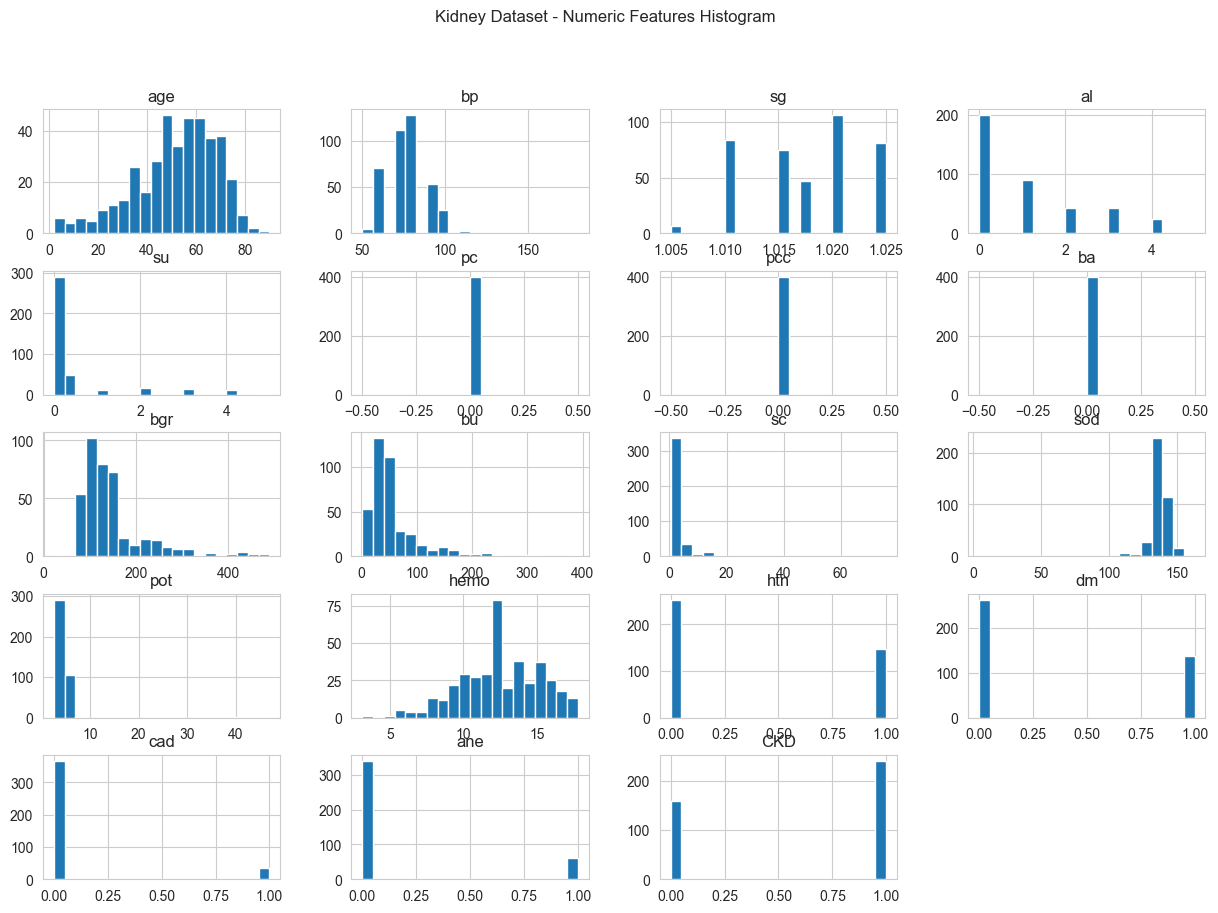

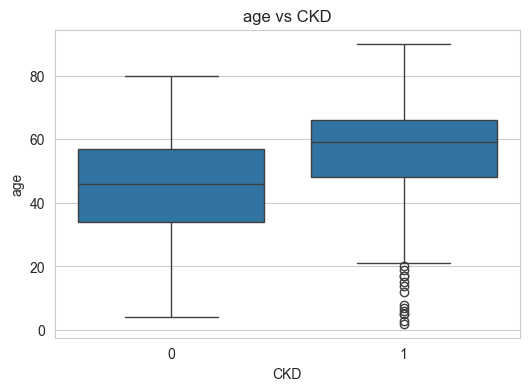

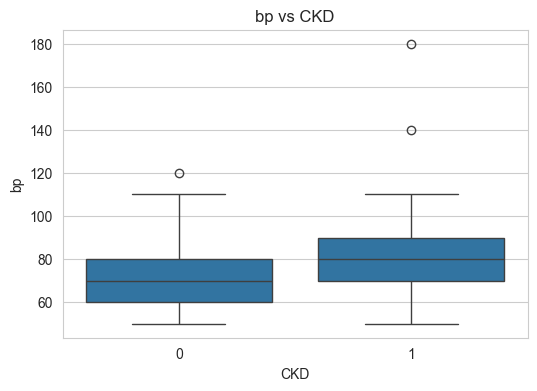

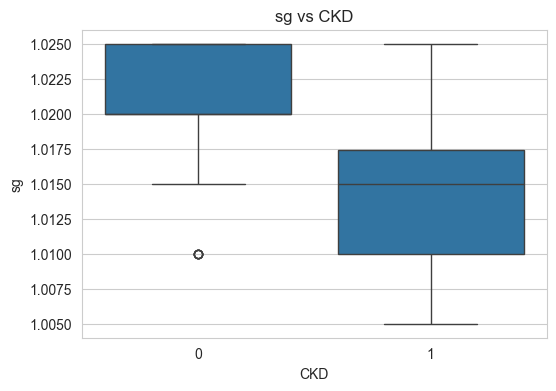

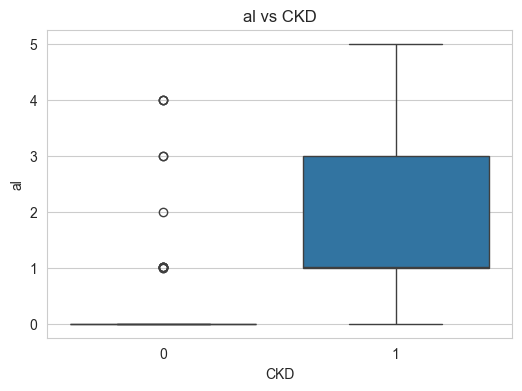

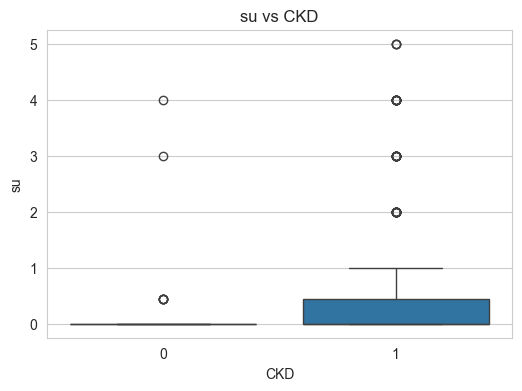

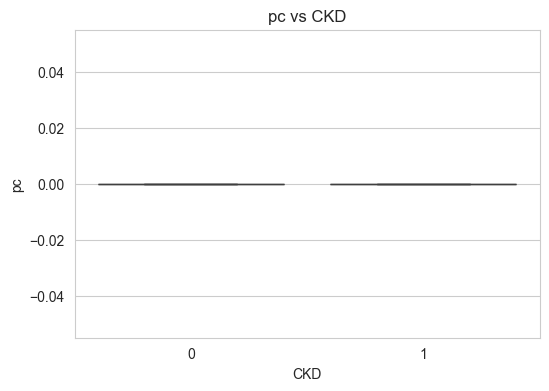

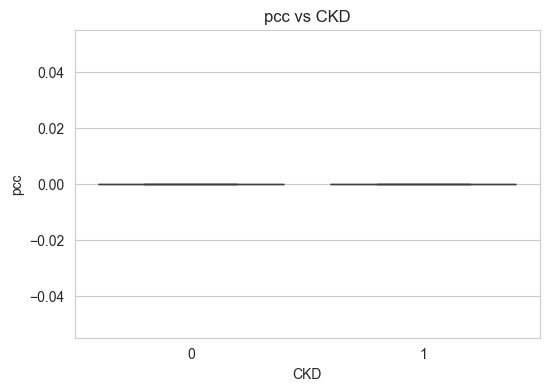

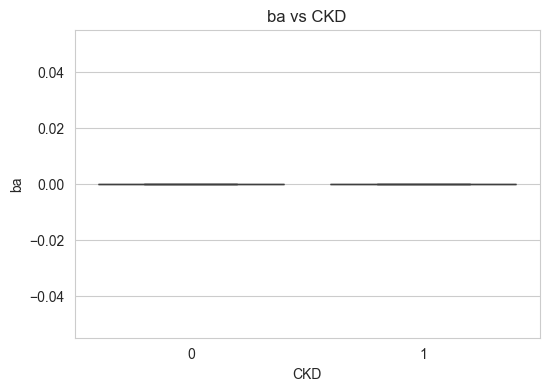

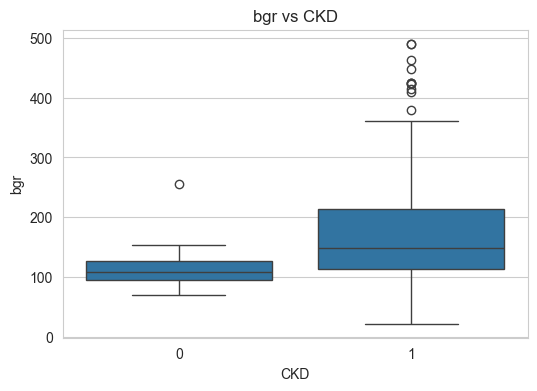

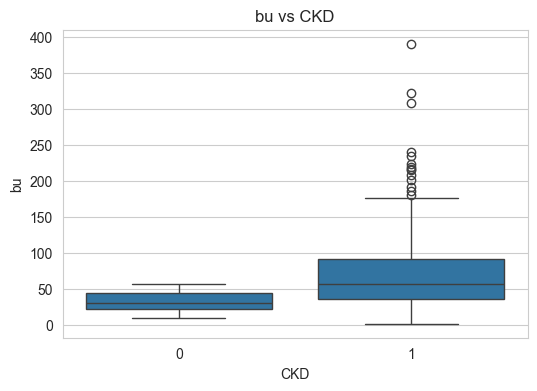

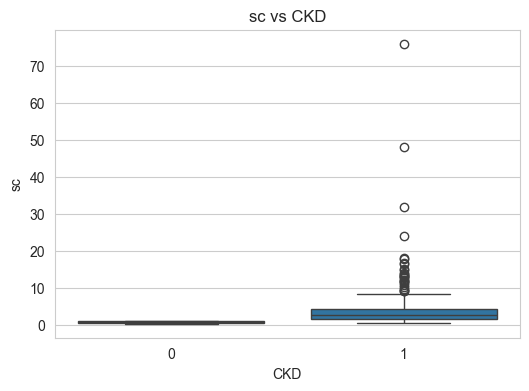

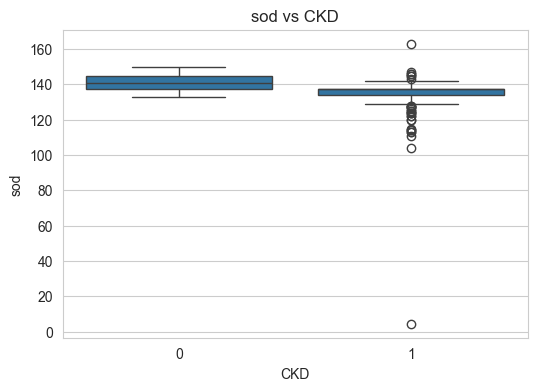

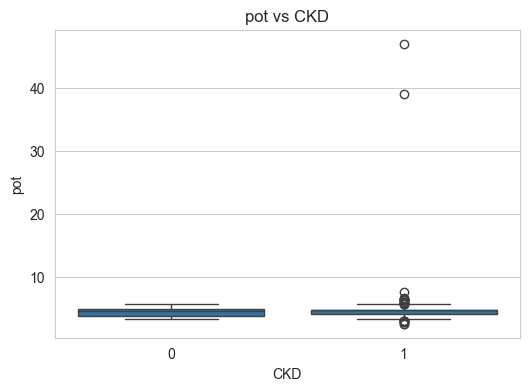

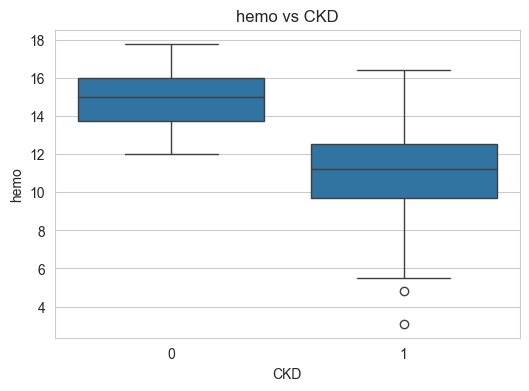

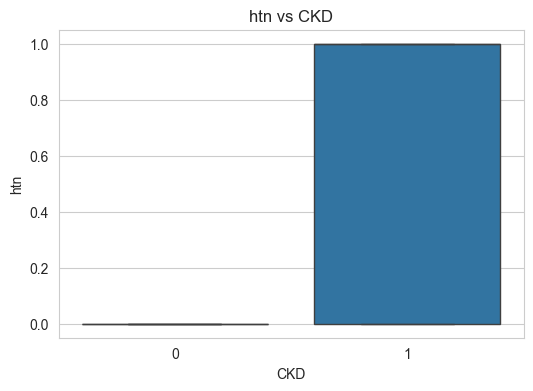

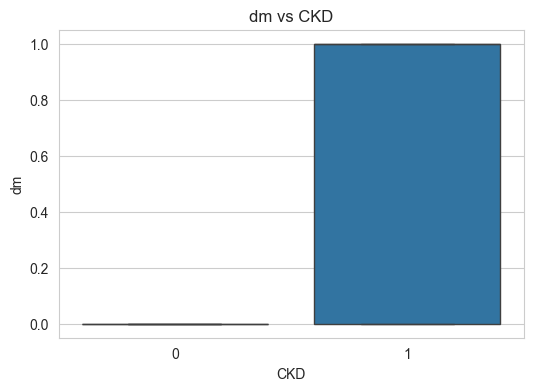

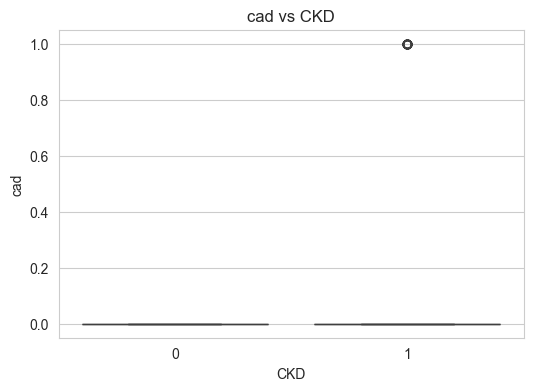

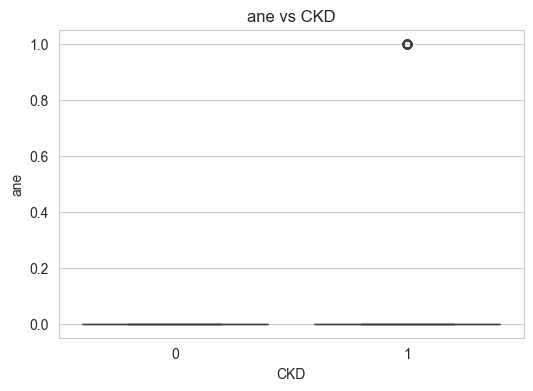

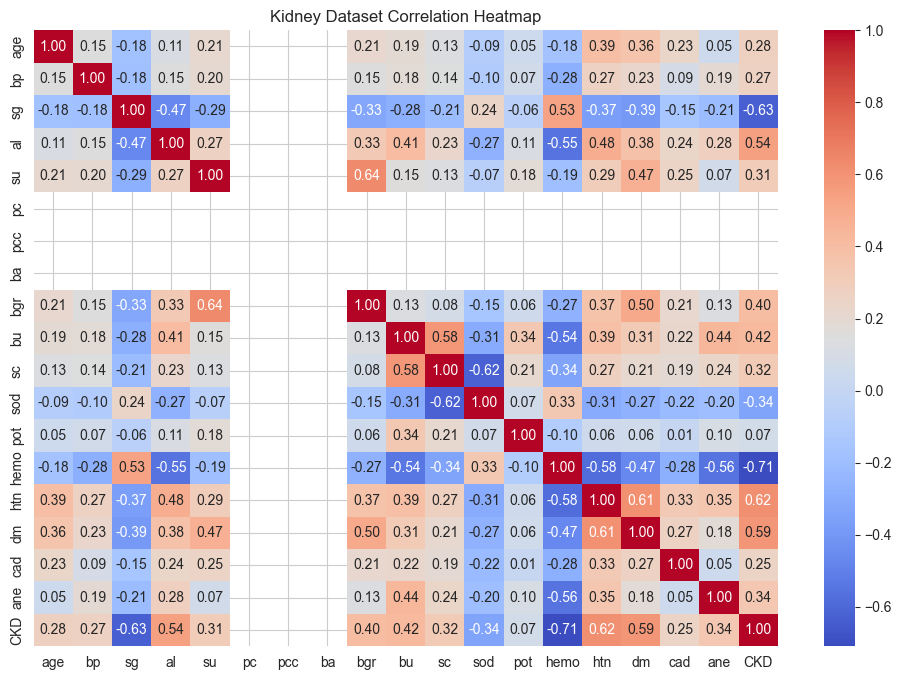


Parkinson Dataset Overview:

   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0      119.992       157.302        74.997         0.00784           0.00007   
1      122.400       148.650       113.819         0.00968           0.00008   
2      116.682       131.111       111.555         0.01050           0.00009   
3      116.676       137.871       111.366         0.00997           0.00009   
4      116.014       141.781       110.655         0.01284           0.00011   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0   0.00370   0.00554     0.01109       0.04374             0.426  ...   
1   0.00465   0.00696     0.01394       0.06134             0.626  ...   
2   0.00544   0.00781     0.01633       0.05233             0.482  ...   
3   0.00502   0.00698     0.01505       0.05492             0.517  ...   
4   0.00655   0.00908     0.01966       0.06425             0.584  ...   

   Shimmer:DDA      NHR     HNR      RPDE   

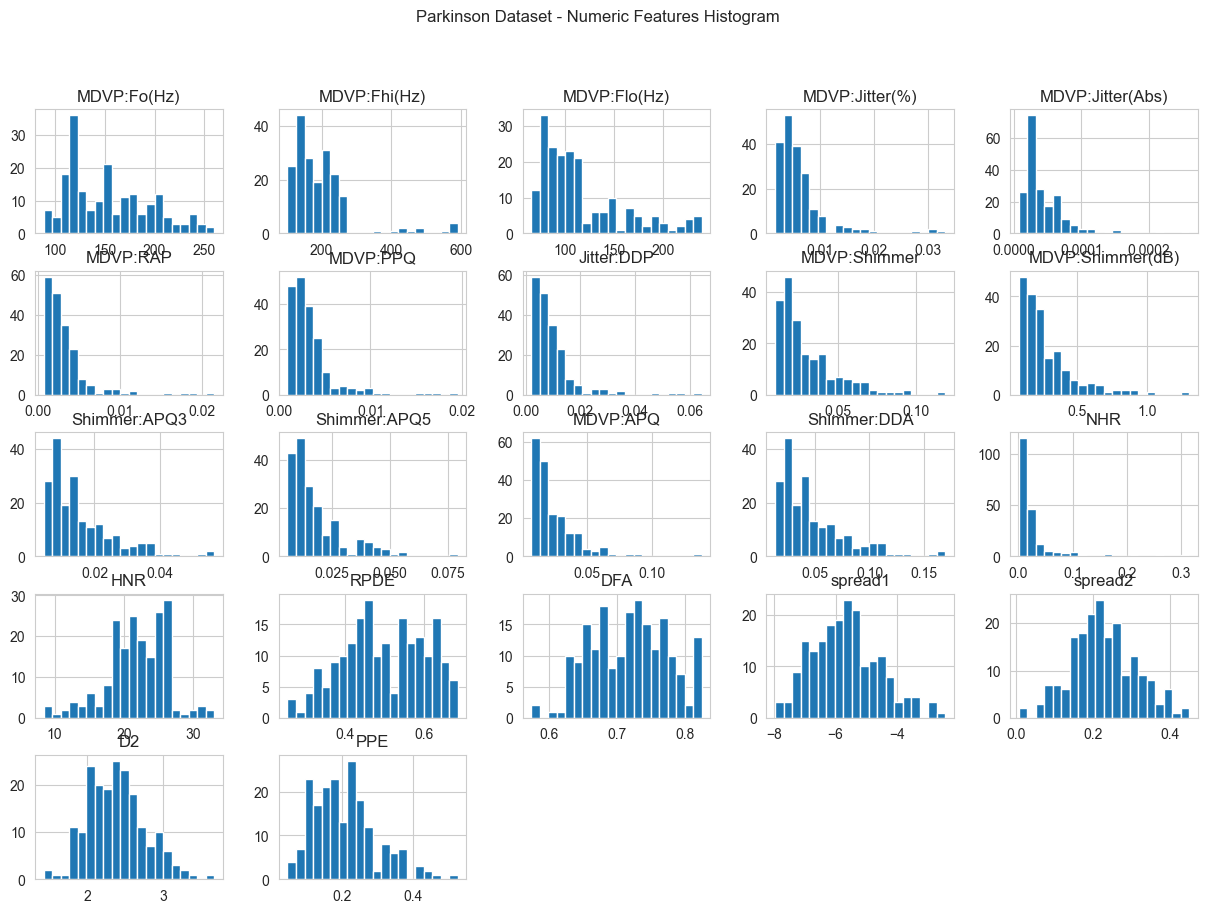

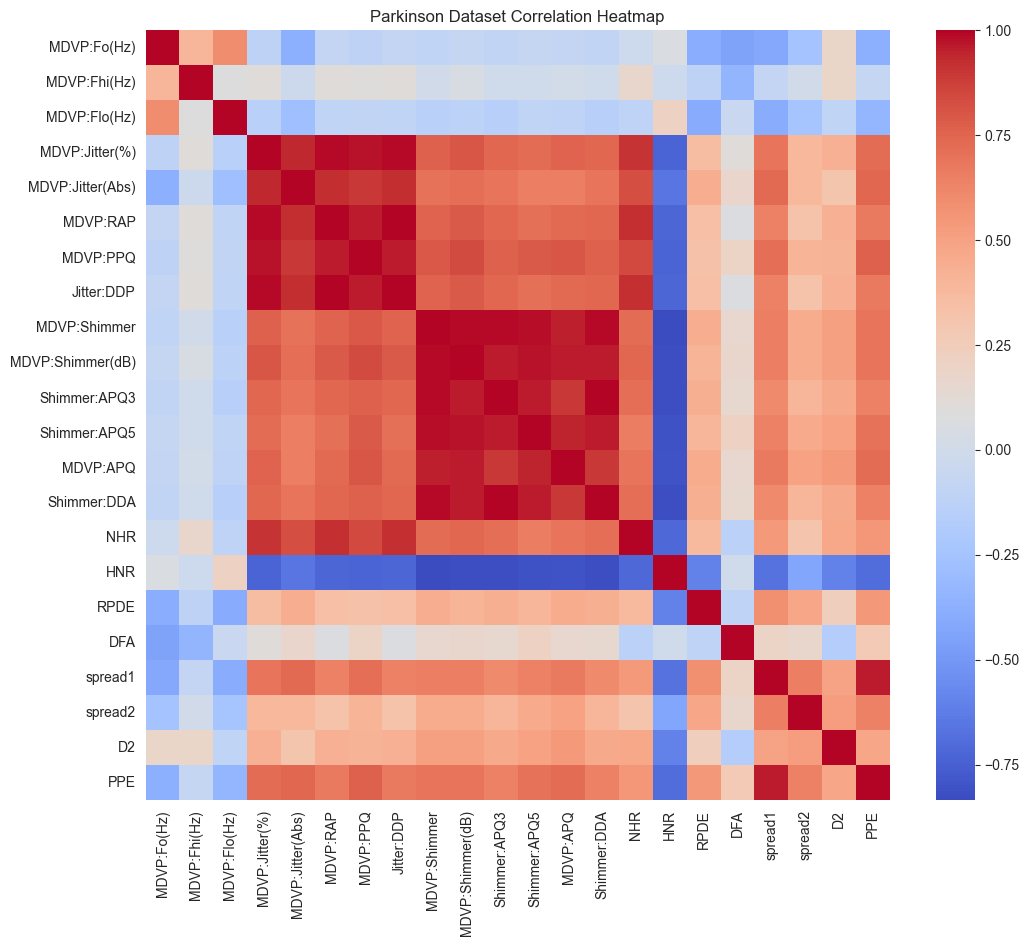


Liver Dataset Overview:

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65       0              0.7               0.1                   187   
1   62       1             10.9               5.5                   699   
2   62       1              7.3               4.1                   490   
3   58       1              1.0               0.4                   182   
4   72       1              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  LiverDisease  
0      3.3       

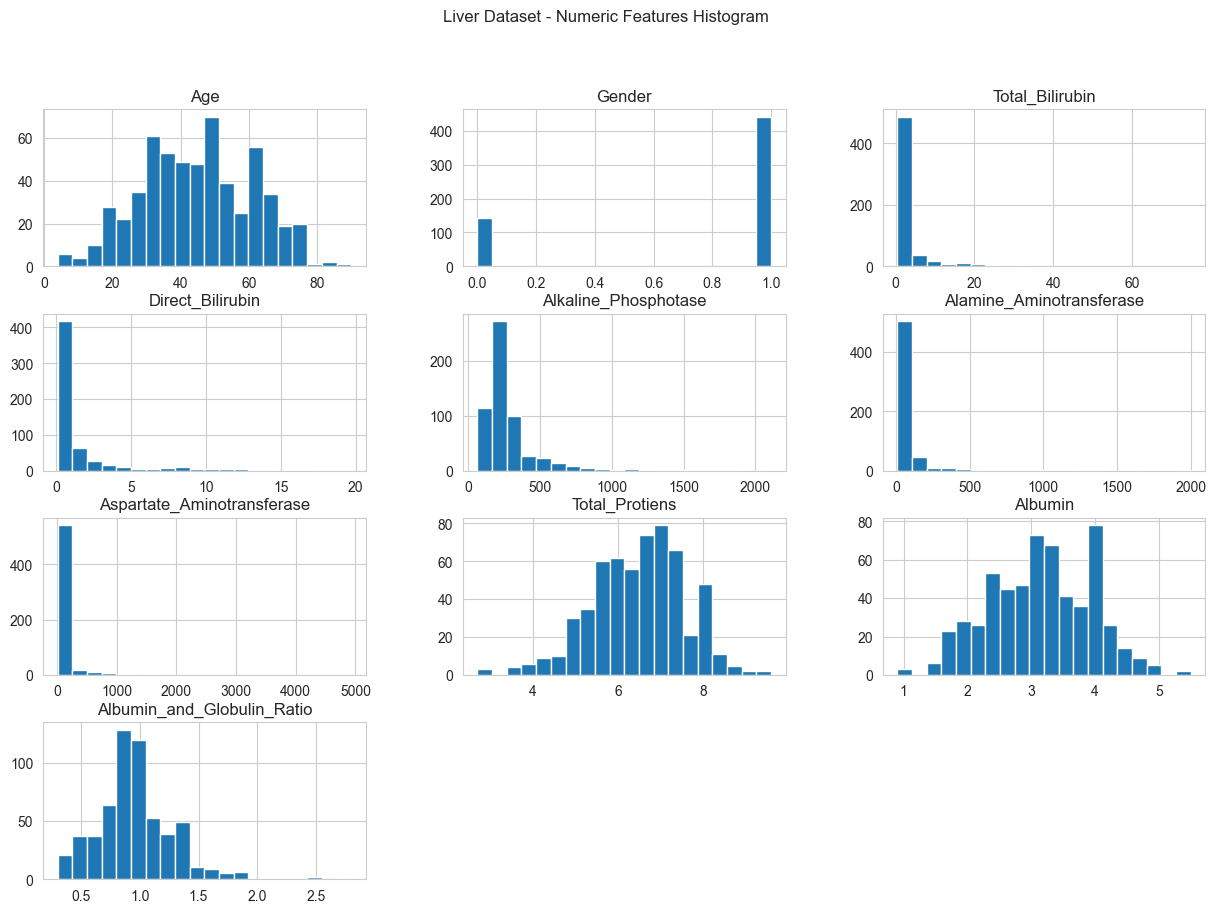

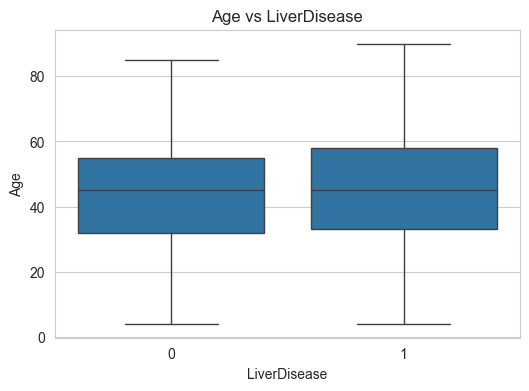

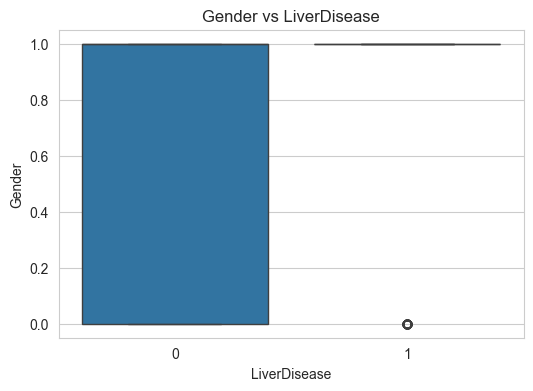

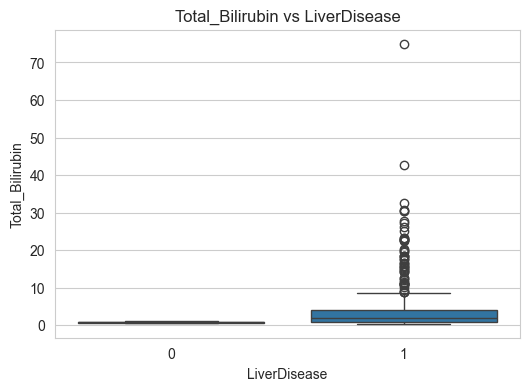

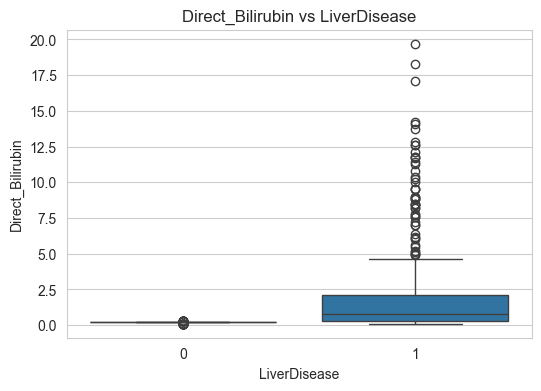

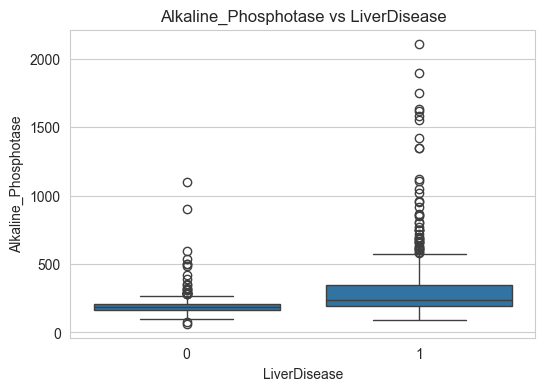

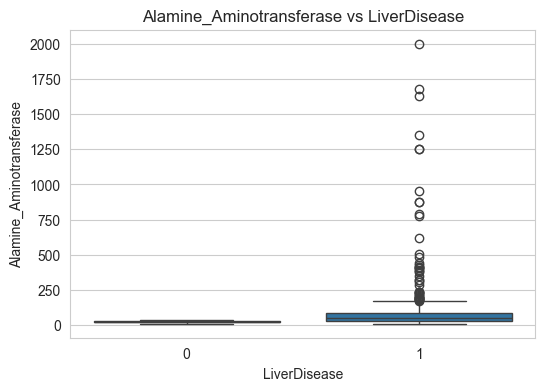

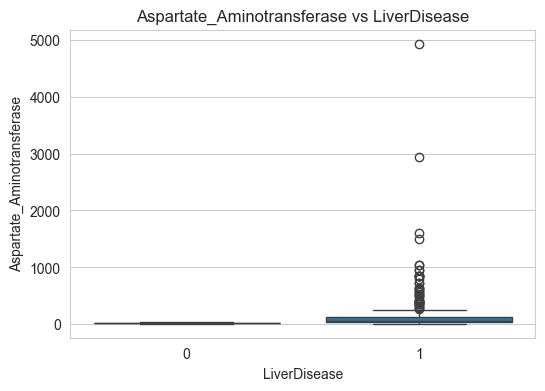

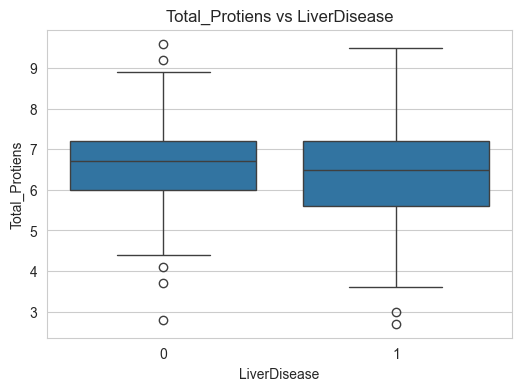

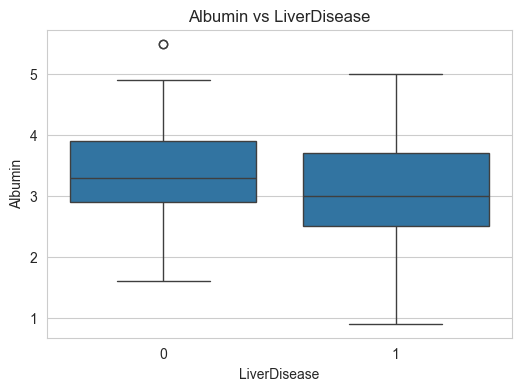

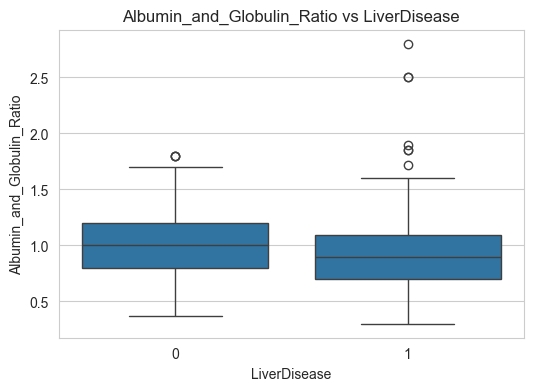

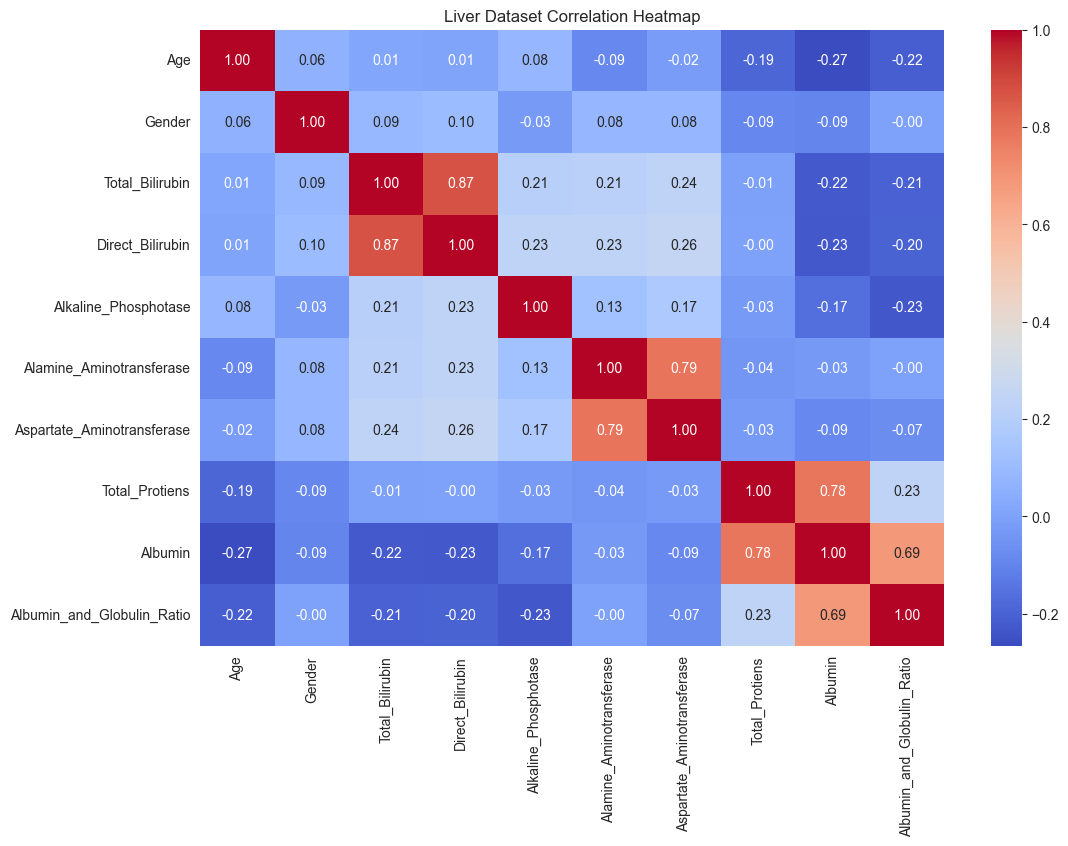

In [25]:
# ===============================
# Step 3: Exploratory Data Analysis
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1️⃣ Kidney Dataset EDA
# ---------------------------
print("Kidney Dataset Overview:\n")
print(kidney_df.head())

# Target column: 'CKD'
print("\nTarget distribution:\n", kidney_df['CKD'].value_counts())

# Remove 'id' from numeric columns
num_cols_kidney = kidney_df.select_dtypes(include=['int64','float64']).columns.drop('id')
kidney_df[num_cols_kidney].hist(figsize=(15,10), bins=20)
plt.suptitle("Kidney Dataset - Numeric Features Histogram")
plt.show()

# Boxplots for numeric columns vs target
for col in num_cols_kidney.drop('CKD'):
    plt.figure(figsize=(6,4))
    sns.boxplot(x='CKD', y=col, data=kidney_df)
    plt.title(f"{col} vs CKD")
    plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12,8))
sns.heatmap(kidney_df[num_cols_kidney].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Kidney Dataset Correlation Heatmap")
plt.show()


# ---------------------------
# 2️⃣ Parkinson's Dataset EDA
# ---------------------------
print("\nParkinson Dataset Overview:\n")
print(parkinson_df.head())

# Target column: 'status'
print("\nTarget distribution:\n", parkinson_df['status'].value_counts())

# Numeric columns for Parkinson (exclude 'status')
num_cols_parkinson = parkinson_df.select_dtypes(include=['int64','float64','float32']).columns.drop('status')
parkinson_df[num_cols_parkinson].hist(figsize=(15,10), bins=20)
plt.suptitle("Parkinson Dataset - Numeric Features Histogram")
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12,10))
sns.heatmap(parkinson_df[num_cols_parkinson].corr(), annot=False, cmap='coolwarm')
plt.title("Parkinson Dataset Correlation Heatmap")
plt.show()


# ---------------------------
# 3️⃣ Liver Dataset EDA
# ---------------------------
print("\nLiver Dataset Overview:\n")
print(liver_df.head())

# Target column: 'LiverDisease'
print("\nTarget distribution:\n", liver_df['LiverDisease'].value_counts())

# Numeric columns for Liver (exclude 'LiverDisease')
num_cols_liver = liver_df.select_dtypes(include=['int64','float64']).columns.drop('LiverDisease')
liver_df[num_cols_liver].hist(figsize=(15,10), bins=20)
plt.suptitle("Liver Dataset - Numeric Features Histogram")
plt.show()

# Boxplots for numeric columns vs target
for col in num_cols_liver:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='LiverDisease', y=col, data=liver_df)
    plt.title(f"{col} vs LiverDisease")
    plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12,8))
sns.heatmap(liver_df[num_cols_liver].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Liver Dataset Correlation Heatmap")
plt.show()

In [26]:
# ===============================
# Step 4: Data Preprocessing & Scaling (Robust, Warnings Removed)
# ===============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ---------------------------
# 1️⃣ Kidney Dataset
# ---------------------------
if 'kidney_df' in globals():
    kidney_df.replace('?', np.nan, inplace=True)

    # Map categorical columns to numeric
    cat_cols_kidney = {
        'rbc': {'normal':1, 'abnormal':0},
        'pc': {'normal':1, 'abnormal':0},
        'pcc': {'notpresent':0,'present':1},
        'ba': {'notpresent':0,'present':1},
        'htn': {'yes':1,'no':0},
        'dm': {'yes':1,'no':0},
        'cad': {'yes':1,'no':0},
        'appet': {'good':1,'poor':0},
        'pe': {'yes':1,'no':0},
        'ane': {'yes':1,'no':0}
    }

    for col, mapping in cat_cols_kidney.items():
        if col in kidney_df.columns:
            kidney_df[col] = kidney_df[col].map(mapping).fillna(0).astype(int)

    # Convert remaining numeric columns
    numeric_cols_kidney = kidney_df.drop(columns=['id','CKD'], errors='ignore').columns
    kidney_df[numeric_cols_kidney] = kidney_df[numeric_cols_kidney].astype(float)
    kidney_df[numeric_cols_kidney] = kidney_df[numeric_cols_kidney].apply(lambda x: np.nan_to_num(x))

    # Features and target
    X_kidney = kidney_df.drop(columns=['id','CKD'], errors='ignore')
    y_kidney = kidney_df['CKD']

    # Scale features
    scaler_kidney = StandardScaler()
    X_kidney_scaled = scaler_kidney.fit_transform(X_kidney)
    joblib.dump(scaler_kidney, "F:/GUVI/guvi project 4/saved_models/kidney_scaler.pkl")

    # Train-test split
    try:
        X_kidney_train, X_kidney_test, y_kidney_train, y_kidney_test = train_test_split(
            X_kidney_scaled, y_kidney, test_size=0.2, random_state=42, stratify=y_kidney
        )
    except ValueError:
        X_kidney_train, X_kidney_test, y_kidney_train, y_kidney_test = train_test_split(
            X_kidney_scaled, y_kidney, test_size=0.2, random_state=42
        )

    print("✅ Kidney dataset preprocessing done. Train shape:", X_kidney_train.shape)


# ---------------------------
# 2️⃣ Parkinson's Disease Dataset
# ---------------------------
if 'parkinson_df' in globals():
    parkinson_df.replace('?', np.nan, inplace=True)

    # Convert all numeric columns to float
    numeric_cols_parkinson = parkinson_df.drop(columns=['status'], errors='ignore').columns
    parkinson_df[numeric_cols_parkinson] = parkinson_df[numeric_cols_parkinson].astype(float)
    parkinson_df[numeric_cols_parkinson] = parkinson_df[numeric_cols_parkinson].apply(lambda x: np.nan_to_num(x))

    # Features and target
    X_parkinson = parkinson_df.drop(columns=['status'], errors='ignore')
    y_parkinson = parkinson_df['status']

    # Scale
    scaler_parkinson = StandardScaler()
    X_parkinson_scaled = scaler_parkinson.fit_transform(X_parkinson)
    joblib.dump(scaler_parkinson, "F:/GUVI/guvi project 4/saved_models/parkinson_scaler.pkl")

    # Train-test split
    try:
        X_parkinson_train, X_parkinson_test, y_parkinson_train, y_parkinson_test = train_test_split(
            X_parkinson_scaled, y_parkinson, test_size=0.2, random_state=42, stratify=y_parkinson
        )
    except ValueError:
        X_parkinson_train, X_parkinson_test, y_parkinson_train, y_parkinson_test = train_test_split(
            X_parkinson_scaled, y_parkinson, test_size=0.2, random_state=42
        )

    print("✅ Parkinson dataset preprocessing done. Train shape:", X_parkinson_train.shape)


# ---------------------------
# 3️⃣ Liver Dataset
# ---------------------------
if 'liver_df' in globals():
    liver_df.replace('?', np.nan, inplace=True)

    # Fill numeric columns with mean
    num_cols_liver = liver_df.select_dtypes(include=['float64','int64']).columns.drop('LiverDisease', errors='ignore')
    liver_df[num_cols_liver] = liver_df[num_cols_liver].fillna(liver_df[num_cols_liver].mean())
    liver_df[num_cols_liver] = liver_df[num_cols_liver].apply(lambda x: np.nan_to_num(x))

    # Map Gender
    if 'Gender' in liver_df.columns:
        liver_df['Gender'] = liver_df['Gender'].map({'Male':1,'Female':0}).fillna(0)

    # Features and target
    X_liver = liver_df.drop(columns=['LiverDisease'], errors='ignore')
    y_liver = liver_df['LiverDisease']

    # Scale
    scaler_liver = StandardScaler()
    X_liver_scaled = scaler_liver.fit_transform(X_liver)
    joblib.dump(scaler_liver, "F:/GUVI/guvi project 4/saved_models/liver_scaler.pkl")

    # Train-test split
    try:
        X_liver_train, X_liver_test, y_liver_train, y_liver_test = train_test_split(
            X_liver_scaled, y_liver, test_size=0.2, random_state=42, stratify=y_liver
        )
    except ValueError:
        X_liver_train, X_liver_test, y_liver_train, y_liver_test = train_test_split(
            X_liver_scaled, y_liver, test_size=0.2, random_state=42
        )

    print("✅ Liver dataset preprocessing done. Train shape:", X_liver_train.shape)

✅ Kidney dataset preprocessing done. Train shape: (320, 24)
✅ Parkinson dataset preprocessing done. Train shape: (156, 22)
✅ Liver dataset preprocessing done. Train shape: (466, 10)


In [27]:
# ===============================
# Step 5: Model Training & Evaluation (Updated)
# ===============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings

warnings.filterwarnings("ignore")

# ===============================
# Models dictionary
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# ===============================
# Helper function: Train & Evaluate
# ===============================
def train_and_evaluate(X, y, disease_name):
    print(f"\n================ {disease_name} Disease Model ================\n")

    # Train-test split (stratified if possible)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Class distribution in training data:\n", y_train.value_counts())

    # Skip if target has only one class
    if len(y_train.unique()) < 2:
        print(f"⚠ Skipping {disease_name} — only one class found in target.\n")
        return None

    best_model = None
    best_acc = 0

    # Train all models
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        print(f"{name} Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_model = model

    # Evaluation
    preds = best_model.predict(X_test)
    print("\nBest Model:", type(best_model)._name_)
    print("Best Accuracy:", round(best_acc, 4))
    print("\nClassification Report:\n", classification_report(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

    # Save model
    model_path = f"F:/GUVI/guvi project 4/saved_models/{disease_name.lower()}_model.pkl"
    joblib.dump(best_model, model_path)
    print(f"✅ {disease_name} model saved to: {model_path}\n")


# ===============================
# 1️⃣ Kidney Disease
# ===============================
X_kidney = kidney_df.drop(columns=['CKD', 'id'], errors='ignore')
y_kidney = kidney_df['CKD']
train_and_evaluate(X_kidney, y_kidney, "Kidney")

# ===============================
# 2️⃣ Liver Disease
# ===============================
X_liver = liver_df.drop(columns=['LiverDisease'], errors='ignore')
y_liver = liver_df['LiverDisease']
train_and_evaluate(X_liver, y_liver, "Liver")

# ===============================
# 3️⃣ Parkinson Disease
# ===============================
X_parkinson = parkinson_df.drop(columns=['status'], errors='ignore')
y_parkinson = parkinson_df['status']
train_and_evaluate(X_parkinson, y_parkinson, "Parkinson")

print("\n✅ All models trained, evaluated, and saved successfully!")


================ Kidney Disease Model ================

Train shape: (320, 24) Test shape: (80, 24)
Class distribution in training data:
 CKD
1    193
0    127
Name: count, dtype: int64
Logistic Regression Accuracy: 0.9625
Random Forest Accuracy: 0.9750
SVM Accuracy: 0.5750


AttributeError: type object 'RandomForestClassifier' has no attribute '_name_'

In [23]:
# ===============================
# Step 6: Train & Save Best Models & Scalers for Streamlit (Fixed)
# ===============================

import pandas as pd
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Directory to save models and scalers
MODEL_DIR = "F:/GUVI/guvi project 4/saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------------------------
# Load cleaned datasets
# ---------------------------
KIDNEY_CSV = "F:/GUVI/guvi project 4/cleaned_data/kidney_cleaned.csv"
LIVER_CSV = "F:/GUVI/guvi project 4/cleaned_data/liver_cleaned.csv"
PARKINSON_CSV = "F:/GUVI/guvi project 4/cleaned_data/parkinson_cleaned.csv"

kidney_df = pd.read_csv(KIDNEY_CSV)
liver_df = pd.read_csv(LIVER_CSV)
parkinson_df = pd.read_csv(PARKINSON_CSV)

# ---------------------------
# Function to train scaler + model and save
# ---------------------------
def train_save_model(df, target_col, model_file, scaler_file):
    # Drop id and target column for features
    X = df.drop(columns=[target_col, 'id'], errors='ignore')
    y = df[target_col]

    # Train scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_scaled, y)

    # Save scaler and model
    joblib.dump(scaler, os.path.join(MODEL_DIR, scaler_file))
    joblib.dump(model, os.path.join(MODEL_DIR, model_file))
    print(f"✅ Saved model: {model_file} & scaler: {scaler_file}")

# ---------------------------
# Train & save all diseases
# ---------------------------
train_save_model(kidney_df, target_col='CKD', model_file='kidney_model.pkl', scaler_file='kidney_scaler.pkl')
train_save_model(liver_df, target_col='LiverDisease', model_file='liver_model.pkl', scaler_file='liver_scaler.pkl')
train_save_model(parkinson_df, target_col='status', model_file='parkinson_model.pkl', scaler_file='parkinson_scaler.pkl')

print("\n✅ All models and scalers are trained and saved for Streamlit integration!")



✅ Saved model: kidney_model.pkl & scaler: kidney_scaler.pkl
✅ Saved model: liver_model.pkl & scaler: liver_scaler.pkl
✅ Saved model: parkinson_model.pkl & scaler: parkinson_scaler.pkl

✅ All models and scalers are trained and saved for Streamlit integration!
